# Assignment 4: Single-Neuron Network with and without PCA

**Nombres de integrantes**

**Diego Marcelo Gonzalez Lujan #588359**

**J. Esteban Bustamante Apodaca #598557**

**Mauricio Alejandro González Campos #555003**

**Inteligencia artificial 2**

**Profesor: Dr Andrés Hernández Gutiérrez**

**Marzo 5 del 2026**

**Damos nuestra palabra que realizamos esta actividad con integridad académica**

# Dataset Description

Para este análisis, seleccionamos el dataset llamado "Single Elder Home Monitoring: Gas and Position". Este conjunto de datos fue creado para desarrollar modelos de monitoreo de seguridad no invasivos para personas mayores que viven solas.

El propósito del dataset es traducir la información recolectada por un arreglo de sensores de gas en un sistema de monitoreo de seguridad. La premisa es que los datos de los sensores de gas, combinados o contrastados con patrones de movimiento, puede servir como indicadores de "anomalías de actividad", un ejemplo de ello es que la persona de mayor edad deje la estufa encendida o que haya una fuga.

* Variables del estudio:

Variables Predictivas (Features): Cada instancia representa una medición temporal de sensores de temperatura, humedad y concentraciones químicas.

Integridad de los Datos: Según la documentación oficial, el dataset no contiene valores nulos ni requiere preprocesamiento de imputación.

* Definición de la Variable Objetivo

La documentación explica que la única división recomendada es la de los datos de referencia. Con esta información pude construir una variable de clasificación de la siguiente manera:

* Clase 1 (Referencia) : Corresponde a los datos del archivo (data_ref), que representan el comportamiento base o de control.

* Clase 0 (Monitoreo): Corresponde al resto de los datos del sensor (database_gas), que representan el monitoreo continuo donde se busca desviaciones respecto a la referencia.

# Data cleaning

En esta parte preparamos los datos para asegurar que sean aptos para el entrenamiento del modelo neuronal y el posterior análisis matemático.

1. Carga y Sincronización: Se cargan los archivos y se normalizan los nombres de las columnas eliminando los espacios en blanco al inicio y al final (usando .strip()), para evitar errores de indexación.

2. Variable Objetivo: Construyo la variable llamada "target", para que todos los registros se marcan como 0 (Monitoreo), mediante un cruce de índices temporales, se actualizan a 1 (Referencia) aquellos registros que coinciden exactamente con el archivo de control.

3. Selección de Características: Elimino la columna timestamp del dataset final, ya que los modelos de Machine Learning necesita una matriz numérica y estática. El resultado es un dataframe (df_final) listo para el análisis, conteniendo únicamente las lecturas de los sensores y la etiqueta de clase.


¡Dataset listo!
Dimensiones finales: (416153, 10)


,temperature,humidity,CO2CosIRValue,CO2MG811Value,MOX1,MOX2,MOX3,MOX4,COValue,target
0,19.48,54.86,128.0,563.0,476.0,731.0,649.0,565.0,128.0,0
1,19.59,54.23,129.0,563.0,477.0,731.0,649.0,565.0,125.0,0
2,19.63,54.05,128.0,566.0,478.0,732.0,649.0,565.0,125.0,0
3,19.64,53.74,128.0,566.0,478.0,732.0,649.0,565.0,125.0,0
4,19.67,53.53,128.0,569.0,480.0,732.0,650.0,565.0,125.0,0


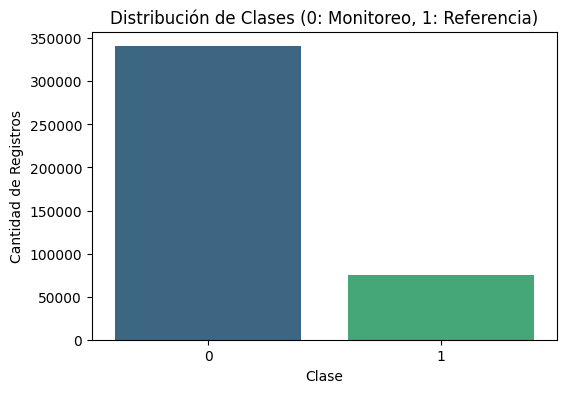

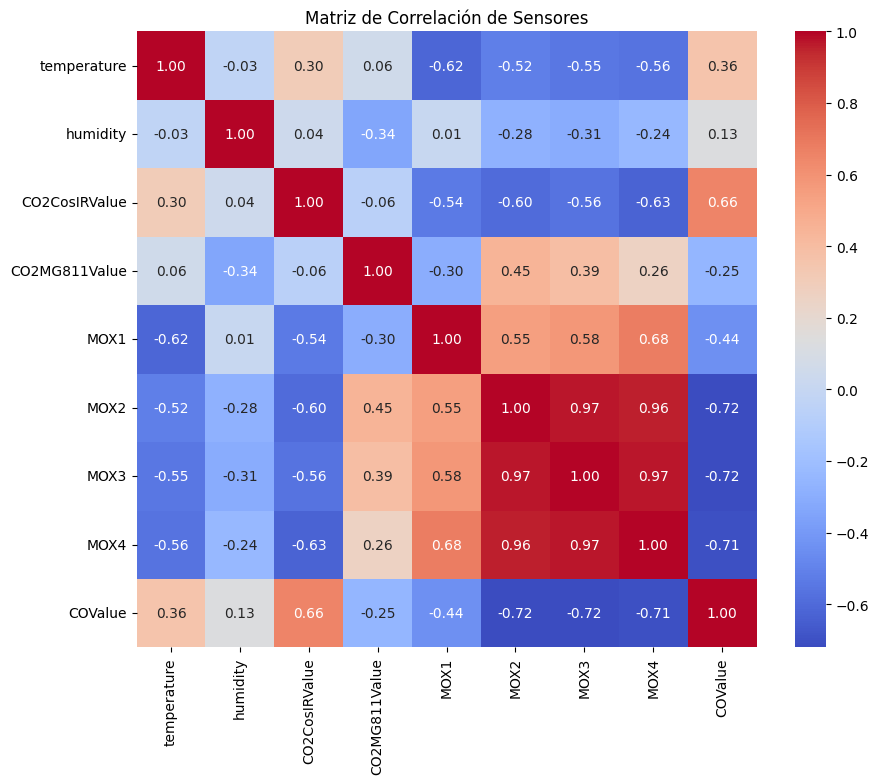

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_gas = pd.read_csv('database_gas.csv')
df_ref = pd.read_csv('data_ref_until_2020-02-13.csv')

# Quita espacios en los nombres de las columnas
df_gas.columns = df_gas.columns.str.strip()
df_ref.columns = df_ref.columns.str.strip()

# Convierte a formato de fecha para poder comparar
df_gas['timestamp'] = pd.to_datetime(df_gas['timestamp'])
df_ref['timestamp'] = pd.to_datetime(df_ref['timestamp'])

# Crea una columna llamada "target" llena de ceros para la Clase 0
df_gas['target'] = 0

# Identificamos qué filas pertenecen al archivo de referencia (Clase 1)
timestamps_referencia = set(df_ref['timestamp'])
df_gas.loc[df_gas['timestamp'].isin(timestamps_referencia), 'target'] = 1

# Crea el dataset final eliminando las fechas
df_final = df_gas.drop(columns=['timestamp'])

print("¡Dataset listo!")
print(f"Dimensiones finales: {df_final.shape}")
display(df_final.head())

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_final, palette='viridis', hue='target', legend=False)
plt.title('Distribución de Clases (0: Monitoreo, 1: Referencia)')
plt.xlabel('Clase')
plt.ylabel('Cantidad de Registros')
plt.show()

plt.figure(figsize=(10, 8))

sns.heatmap(df_final.drop(columns=['target']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Sensores')
plt.show()

# Exploratory Data Analysis

Al revisar los gráficos y estadísticas, identificamos tres puntos clave para mi análisis:

1. Redundancia (Mapa de Calor): Observe que los sensores MOX1 al MOX4 tiene una correlación superior a 0.90. Esto justifica el uso de PCA, ya que podemos comprimir estas 4 variables repetidas en un solo componente sin perder información, optimizando la red neuronal.

2. Clases (Grafico de Barras): Se confirma que la Clase 0 es mayoritaria frente a la Clase 1. Esto quiere decir que la referencia es solo un periodo base y nuestra neurona aprenderá principalmente de la varianza de la operación diaria.

3. Escalas (Estadísticas): Note que el sensor C02 ronda los 500 mientras la temperatura está en 20. Por lo tanto, si alimentamos la red neuronal directamente con estos datos, el modelo de daría mayor peso matemático al CO2 simplemente por su magnitud.


## Design and Training of the Single-Neuron Model

1. Train/validation/test split

En este primer paso separaremos nuestro conjunto de datos en las variables predictivas (X) y la etiqueta objetivo (y). Utilizaremos la función "train_test_split" para dividir los datos, asignando un 80% para el proceso de entrenamiento y un 20% para la prueba final. Esta separación es importante para poder evaluar el rendimiento real del modelo con información que nunca ha visto, confirmando que nuestro modelo aprenderá a generalizar y no solo a memorizar.




In [ ]:
from sklearn.model_selection import train_test_split

# Separamos las características (X) de la etiqueta (y)
X = df_final.drop(columns=['target'])
y = df_final['target']

# Usamos el 80% para el entrenamiento y 20% de la prueba final
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Registros para entrenamiento: {X_train_full.shape[0]}")
print(f"Registros para prueba final : {X_test.shape[0]}")

Registros para entrenamiento: 332922
Registros para prueba final : 83231


Al ejecutar la función de separación, el sistema nos confirma cómo quedó distribuido nuestro conjunto de datos limpio:

**Registro para entrenamiento (332922)**: Este bloque de datos será el material de estudio de nuestra red neuronal. Su propósito es permitir que el modelo identifique y aprenda matemáticamente los patrones subyacentes que diferencian el estado de monitoreo continuo del estado de referencia.

**Registros para prueba final (83231)** : Estos datos mantiene estrictamente aislados durante la fase de aprendizaje para evitar la filtración de información. Su función es proporcionar una métrica imparcial del rendimiento del modelo, permitiendo evaluar su capacidad de generalización ante datos no vistos y descartar anomalías como el sobreajuste.


2. Feature standardisation

En el análisis exploratorio, nuestras variables tienen magnitudes muy distintas. Si no estandarizamos los datos, la red neuronal le dará un peso matemático mucho mayor al CO2 por su escala. Para evitar este sesgo, utilizamos "StandardScaler" para transformar todas las variables de modo que tengan una media de cero y una desviación estándar de uno.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Inicialización del Escalador
scaler = StandardScaler()

# Transformación
# fit_transform calcula la media y desviación de cada columna y las transforma

X_train_std = scaler.fit_transform(X_train_full)

X_test_std = scaler.transform(X_test)

print("--- Proceso de Estandarización Completado ---")
print("Dimensiones de la matriz de entrenamiento estandarizada:", X_train_std.shape)
print(f"Media global de los datos transformados: {np.mean(X_train_std):.2f} (Debe ser ~0)")
print(f"Desviación estándar global: {np.std(X_train_std):.2f} (Debe ser ~1)")

print("\nPrimeros 3 registros estandarizados:\n", X_train_std[:3])

--- Proceso de Estandarización Completado ---
Dimensiones de la matriz de entrenamiento estandarizada: (332922, 9)
Media global de los datos transformados: 0.00 (Debe ser ~0)
Desviación estándar global: 1.00 (Debe ser ~1)

Primeros 3 registros estandarizados:
 [[ 0.31576205  0.53157525 -1.21857641 -0.48931033  0.73653639  0.87190562
   0.50051448  0.92617582 -0.44767851]
 [-1.4552988  -0.4466819   0.06624916 -0.94734821  1.13825718  0.04058337
   0.30784679  0.29373431 -0.69773723]
 [ 0.22438053 -1.03593798  0.27182126 -0.80421137  0.05361104 -0.37507776
  -0.1875844  -0.19816465  0.21914474]]


Al analizar la salida del proceso de transformación, confirmamos matemáticamente que los datos se encuentran en condiciones óptimas para alimentar nuestra red neuronal:

* **Dimensiones de la matriz de entrenamiento estandarizada:** El resultado indica que el escalador procesó los 332,922 registros que separamos previamente para la fase de aprendizaje, conservando las 9 variables. Esto significa que no hubo pérdida de dimensionalidad durante la transformación.


* **Media global de los datos transformados:** Este resultado significa que el promedio de todos los datos ahora es exactamente cero. Esto es importante porque evita que la red neuronal dando más importancia a los sensores que tienen números grandes (como el CO2 llega a 500) frente a los que tienen números pequeños (como la temperatura en 20).

* **Desviación estándar global:** Este valor confirma que todos los sensores han sido ajustados a una misma escala. Esto significa que todos los sensores compiten en igualdad de condiciones, lo que ayuda a que el modelo aprenda de forma mucho más rápida y estable.

* **Primeros 3 registros estandarizados:** Al ver la muestra de los números resultantes, notamos que ya no tenemos valores en los cientos, tenemos números pequeños que indican qué tanto se desvía un valor de su promedio. Estos números pequeños son el formato ideal para que nuestra única neurona procese la información sin sobrecargarse.


3. Model architecture (one neuron, and Sigmoid activation)

Para construir nuestra red neuronal, implementamos un modelo secuencial con una sola neurona. Como nuestro objetivo es predecir si existe o no un evento de gas, aplicamos la función de activación "Sigmoide" para que el modelo nos devuelva un valor interpretado como una probabilidad entre 0 y 1. Para el proceso de aprendizaje, configuramos la pérdida matemática como entropía cruzada binaria y utilizados el optimizador "Adam". Además agregamos una parada temprana "early_stop" que detiene el entrenamiento automáticamente si el modelo deja de mejorar.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# Definimos la arquitectura: una sola neurona con activación Sigmoide

model = models.Sequential([
    layers.Dense(1, activation='sigmoid', input_shape=(X_train_std.shape[1],))
])

# Creamos un early stop para que no continue si el val_loss no mejora por 5 epochs

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Configuramos el optimizador Adam
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

# Compilamos el modelo con la función de pérdida y la métrica de exactitud

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

El resumen generado confirma que la estructura de la red neuronal se creó correctamente y cumple con los requisitos del diseño.

* **Tipo de Capa (Dense):** La tabla nos muestra una sola capa tipo "Dense" lo que significa que esta densa o totalmente conectada. Al tener solo esta capa, confirmamos que estamos implementando la red de una sola neurona, la cual es el modelo base para problemas de clasificación binaria.

* **Forma de Salida (Output Shape):** El valor (None, 1) significa que el modelo está diseñado para procesar cualquier cantidad de registros simultáneamente y siempre devolverá un único valor de salida por cada registro.

* **Parámetros Entrenables:** Este es el dato nos ayuda en confirmar que nuestra red está bien conectada a los datos. La neurona tiene **10** parámetros porque recibe información de nuestras **9** variables predictivas.


4.  Loss function (binary cross-entropy)

Por último en esta fase, procedemos a ejecutar el aprendizaje de nuestra red neuronal. Para lograrlo, utilizamos la función "fit" y configuramos los hiperparametros clave que controlarán cómo el modelo procesa la información:

* **Épocas (epochs = 20):** Definimos un máximo de 20 iteraciones sobre nuestro conjunto de datos de entrenamiento para que el algoritmo encuentre los patrones matemáticos correctos.

* **Tamaño de lote (batch_size = 32):** Configuramos la red para que analice los datos en pequeños grupos de 32 registros a la vez antes de actualizar sus pesos. Esto hace que el entrenamiento sea más eficiente y estable.

* **Validación interna (validation_split = 0.2)**: Le indicamos al modelo que separe el 20% de los datos para usarlos al final de cada época. Esto nos permite monitorear el rendimiento en tiempo real con datos que la neurona no usó para entrenar.

Todo este proceso de aprendizaje queda guardado en la variable "history", la cual contiene los registros exactos de pérdida y exactitud que utilizaremos en la Sección 3 de la tarea.


In [ ]:
# Entrenamos el modelo y guardamos el registro en la variable "history"

history = model.fit(
    X_train_std,
    y_train_full,
    epochs=20,             # cantidad de iteraciones completas
    batch_size=32,         # cantidad de muestras por actualización de gradiente
    validation_split=0.2,  # 20% reservado para validación interna
    verbose=1,
    callbacks=[early_stop] # El early stop descrito previamente
)

Epoch 1/20
8324/8324 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.9695 - loss: 0.1072 - val_accuracy: 0.9863 - val_loss: 0.0360
Epoch 2/20
8324/8324 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.9885 - loss: 0.0324 - val_accuracy: 0.9885 - val_loss: 0.0317
Epoch 3/20
8324/8324 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.9893 - loss: 0.0282 - val_accuracy: 0.9875 - val_loss: 0.0305
Epoch 4/20
8324/8324 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9897 - loss: 0.0281 - val_accuracy: 0.9889 - val_loss: 0.0299
Epoch 5/20
8324/8324 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9894 - loss: 0.0286 - val_accuracy: 0.9890 - val_loss: 0.0299
Epoch 6/20
8324/8324 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9895 - loss: 0.0276 - val_accuracy: 0.9901 - val_loss: 0.0303
Epoch 7/20
8324/8324 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.9896 - loss: 0.0278 - val_accuracy: 0.9897 - val_loss: 0.0302
Epoch 8/20
8324/8324 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9896 - loss: 0

# Learning Curve Analysis

Durante la sección anterior, todo el registro del entrenamiento (pérdida y exactitud por cada iteración) quedó almacenado en la variable "history".

En esta sección, utilizaremos la librería "matplotlib" para extraer esos datos y generar las gráficas comparativas.

* **Training and validation accuracy vs epochs:** Para observar cómo mejoró la capaciada de predicción de la neurona tanto en los datos de estudio como en los datos de prueba interna.

* **Training and validation loss vs epochs:** Para visualizar la eficiencia del optimizador Adam al reducir el error matemático iteración tras iteración.

Al graficar estas métricas lado a lado, podremos diagnosticar el estadode nuestra red neuronal y determinar si el modelo presenta subajuste, sobreajuste o un ajuste apropiado.


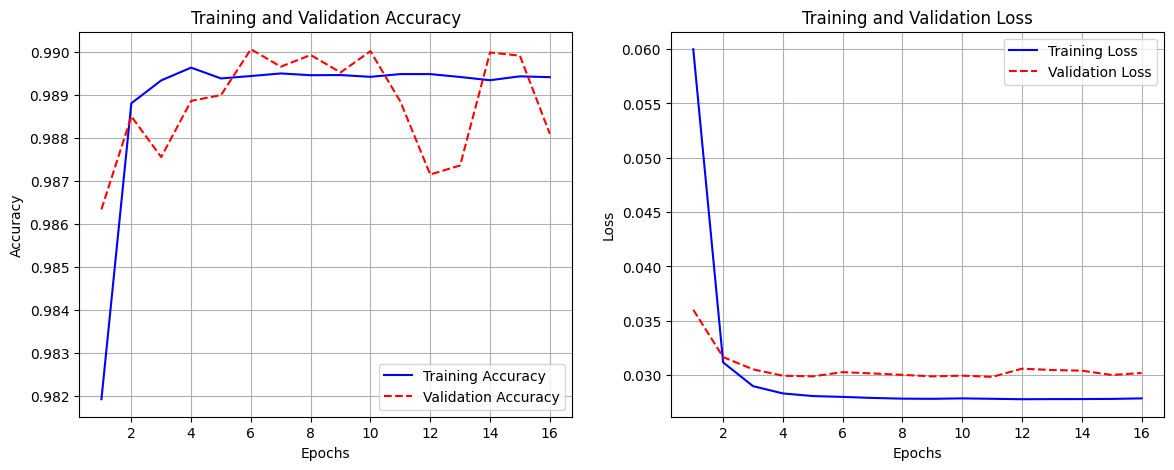

In [ ]:
import matplotlib.pyplot as plt

# Extraemos los datos del entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Creamos un vector para el eje x
epochs = range(1, len(acc) + 1)

# Gráficas lado a lado
plt.figure(figsize=(14, 5))

# Gráfica de Exactitud
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy') # Línea azul continua
plt.plot(epochs, val_acc, 'r--', label='Validation Accuracy') # Línea roja punteada
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


# Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.show()

Al observar las gráficas, podemos concluir que el modelo presenta un **ajuste apropiado**.

* **Análisis de la Pérdida:** Las curvas de entrenamiento y validación caen rápidamente y se estabilizan en valores muy bajos (cerca de 0.030). La curva de validación se mantiene plana y no vuelve a subir, lo que descarta el sobreajuste.

* **Análisis de la Exactitud:** Ambas métricas alcanzan un alto rendimiento (aproximadamente 98.9%) desde las primeras épocas. Las ligeras oscilaciones en la validación son fluctuaciones minimas causadas por el optimizador Adam. Esto significa que esta alta exactitud en ambos conjuntos descarta el subajuste.

# Model Evaluation and Testing Data

2601/2601 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


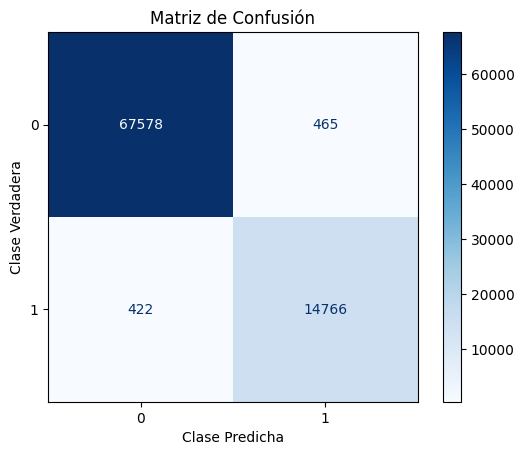


Precision: 0.9695
Recall: 0.9722
Especificidad: 0.9932
F1-Score: 0.9708


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Se realizan las predicciones con los datos de prueba estandarizados
y_pred_proba = model.predict(X_test_std)
y_pred = (y_pred_proba > 0.5).astype(int)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.show()

# Cálculo de las métricas de precisión, recall, especificidad y F1-Score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
TN = cm[0, 0]
FP = cm[0, 1]
specificity = TN / (TN + FP)
f1 = f1_score(y_test, y_pred)

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Especificidad: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")

La matriz de confusión es una herramienta con la función de demostrar el rendimiento del modelo de clasificación al mostrar el número de predicciones correctas e incorrectas realizadas por el modelo para cada paso, comparándolas con los valores reales. De esta tabla y sus resultados podemos obtener las siguientes métricas:

* **Precisión:** Esta métrica representa la proporción de las identificaciones positivas correctas que realizo el modelo con los datos de prueba. Una alta precisión demuestra que hay pocos falsos positivos.

* **Recall (Sensibilidad):** Esta métrica representa la proporción de los verdaderos positivos que fueron correctamente identificados por el modelo. Una alta sensibilidad demuestra que casi todas sus predicciones positivas fueron reales.

* **Specificity (Especificidad):** Esta métrica mide la proporción de los verdaderos negativos que fueron correctamente identificados por el modelo. Una alta especificidad demuestra que casi todas sus predicciones negativas fueron reales, básicamente lo opuesto a la sensibilidad aplicado a la clase 1.

* **F1-Score:** Esta métrica es la media armónica entre la precisión y el recall, representa la capacidad del modelo para detectar los positivos y la confiabilidad de esas detecciones. Un F1-score alto demuestra que el modelo tiene la capacidad de clasificar correctamente los casos positivos sin generar tantos falsos.

Para la aplicación de este modelo, la métrica que se podría considerar la más importante sobre las demás seria la **sensibilidad** ya que la capacidad de detectar eventos reales correctamente es más importante a comparación de situaciones como por ejemplo de falsa alarma. Los falsos negativos son el resultado de clasificar un evento peligroso como lo es una fuga de gas como algo normal lo que podría llevar a grandes consecuencias por lo que reducir el número de estos es de suma importancia.

El modelo tiene un comportamiento aceptable. Las métricas superan el 0.95, y la métrica de **sensibilidad** con 0.9722 es adecuado pero podría ser mejor como la **especificidad** con un 0.9932. Aun así el modelo demuestra predecir correctamente los datos de prueba.


# Save the Model

In [ ]:
import os

# Definir el nombre del archivo para guardar el modelo
model_filename = 'single_neuron_model_ClasificacionDeMonitoreo.h5'

# Guardar el modelo en formato Keras (.h5)
model.save(model_filename)

# Definir el nombre del archivo del modelo guardado
model_filename = 'single_neuron_model_ClasificacionDeMonitoreo.h5'

# Cargar el modelo
loaded_model = tf.keras.models.load_model(model_filename)

print("Modelo cargado exitosamente.")
loaded_model.summary()

# Realizar predicciones al modelo cargado con los datos de prueba
predictions_loaded_model = loaded_model.predict(X_test_std)

# Convertir las probabilidades a clases binarias (0 o 1)
predicted_classes_loaded_model = (predictions_loaded_model > 0.5).astype(int)

# Matriz de confusión del modelo cargado
cm_loaded = confusion_matrix(y_test, predicted_classes_loaded_model)
TN_loaded = cm_loaded[0, 0]
FP_loaded = cm_loaded[0, 1]
specificity_loaded = TN_loaded / (TN_loaded + FP_loaded)

# Calculo de las métricas
accuracy_loaded = accuracy_score(y_test, predicted_classes_loaded_model)
precision_loaded = precision_score(y_test, predicted_classes_loaded_model)
recall_loaded = recall_score(y_test, predicted_classes_loaded_model)
f1_loaded = f1_score(y_test, predicted_classes_loaded_model)

print(f"\nResultados del modelo cargado en los datos de prueba:")
print(f"Accuracy: {accuracy_loaded:.4f}")
print(f"Precision: {precision_loaded:.4f}")
print(f"Recall: {recall_loaded:.4f}")
print(f"Especificidad: {specificity_loaded:.4f}")
print(f"F1-Score: {f1_loaded:.4f}")

Modelo cargado exitosamente.


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12 (52.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

2601/2601 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step

Resultados del modelo cargado en los datos de prueba:
Accuracy: 0.9893
Precision: 0.9695
Recall: 0.9722
Especificidad: 0.9932
F1-Score: 0.9708


Una vez guardado el modelo en un archivo .h5 que guarda la arquitectura del modelo, los pesos, la configuración de entrenamiento y su estado, se puede apreciar que contiene los mismos resultados en las métricas con los mismos datos por lo que se podría confirmar que se guardó correctamente. Es de suma importancia y utilidad el guardar un modelo, ya que facilita el proceso de usar el modelo para nuevas predicciones sin tener que reentrenarlo.

# Principal Component Analysis (PCA) Extension

Gráfica de la varianza explicada acumulada


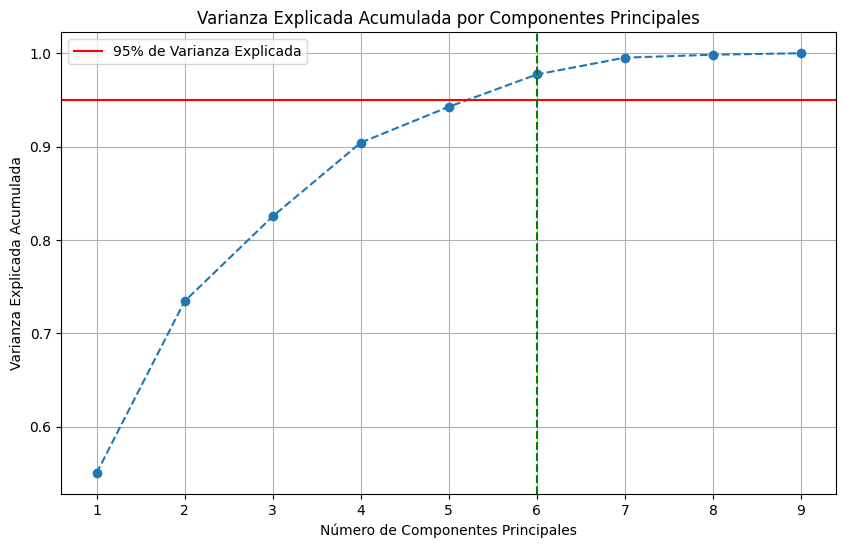

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Se usa X_train_std ya que ya esta estandarizado con StandardScaler
pca = PCA()
pca.fit(X_train_std)

# Varianza explicada por cada componente
explained_variance_ratio = pca.explained_variance_ratio_

# Varianza explicada acumulada
cumulative_variance = np.cumsum(explained_variance_ratio)

# Encontrar el número de componentes para el 95% de la varianza
n_components_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1

print(f"Gráfica de la varianza explicada acumulada")

# Gráfico de la varianza explicada acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% de Varianza Explicada')
plt.axvline(x=n_components_95, color='g', linestyle='--')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.legend()
plt.show()

Como se puede observar, no se alcanza al 90% de la varianza explicada hasta tener cuatro componentes, y se alcanza un porcentaje mayor al 95% con 6 componentes.

Con el PCA, se redujeron la cantidad de dimensiones de 9 (sin contar la columna timestamp que fue borrada), a 6 dimensiones con los seis componentes, el cual es la misma cantidad de dimensiones que si MOX1, MOX2, MOX3 y MOX4 fueran reducidos a una variable, aunque esto no significa que esto es lo que haya sucedido. La existencia de estas cuatro variables es redundante, ya que como visto previamente, tienen correlaciones altas entre sí mismas, especialmente MOX2 a MOX4, las cuales tienen correlaciones mayores a 0.95.


# Train a New Single-Neuron model using PCA features

In [ ]:
# Se usa el n_components_95 determinado previamente (6 componentes)
pca_final = PCA(n_components=n_components_95)

X_train_pca = pca_final.fit_transform(X_train_std)
X_test_pca = pca_final.transform(X_test_std)

print(f"Dimensiones de X_train después de PCA: {X_train_pca.shape}")
print(f"Dimensiones de X_test después de PCA: {X_test_pca.shape}")
print("Cantidad de entradas, Componentes")

# Definimos la arquitectura del modelo con una sola neurona y activación Sigmoide
model_pca = models.Sequential([
    layers.Dense(1, activation='sigmoid', input_shape=(X_train_pca.shape[1],))
])

# Creamos un early stop para que no continúe si el val_loss no mejora por 5 epochs
early_stop_pca = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Configuramos el optimizador Adam
optimizer_pca = tf.keras.optimizers.Adam(learning_rate=0.01)

# Compilamos el modelo con la función de pérdida (loss) y la métrica de exactitud (accuracy)
model_pca.compile(
    optimizer=optimizer_pca,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_pca.summary()



Dimensiones de X_train después de PCA: (332922, 6)
Dimensiones de X_test después de PCA: (83231, 6)
Cantidad de entradas, Componentes


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamos el modelo
history_pca = model_pca.fit(
    X_train_pca,
    y_train_full,
    epochs=20,             # cantidad de iteraciones completas
    batch_size=32,         # cantidad de muestras por actualización de gradiente
    validation_split=0.2,  # 20% reservado para validación interna
    verbose=1,
    callbacks=[early_stop_pca] # El early stop
)



Epoch 1/20
8324/8324 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9565 - loss: 0.1292 - val_accuracy: 0.9769 - val_loss: 0.0678
Epoch 2/20
8324/8324 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9758 - loss: 0.0659 - val_accuracy: 0.9758 - val_loss: 0.0674
Epoch 3/20
8324/8324 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - accuracy: 0.9762 - loss: 0.0672 - val_accuracy: 0.9765 - val_loss: 0.0669
Epoch 4/20
8324/8324 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9759 - loss: 0.0658 - val_accuracy: 0.9772 - val_loss: 0.0677
Epoch 5/20
8324/8324 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.9767 - loss: 0.0653 - val_accuracy: 0.9770 - val_loss: 0.0671
Epoch 6/20
8324/8324 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.9760 - loss: 0.0658 - val_accuracy: 0.9770 - val_loss: 0.0671
Epoch 7/20
8324/8324 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9767 - loss: 0.0651 - val_accuracy: 0.9760 - val_loss: 0.0673
Epoch 8/20
8324/8324 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9761 - loss: 0

2601/2601 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


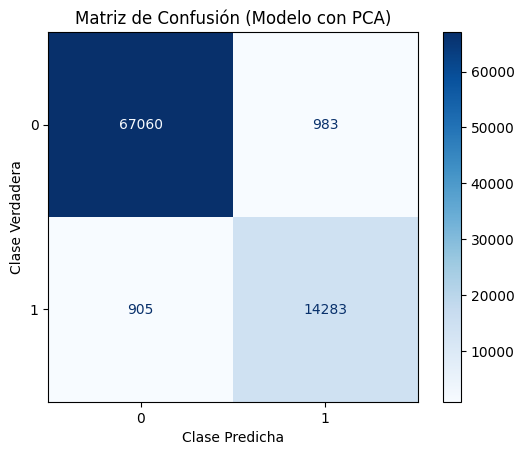


Métricas del Modelo con PCA:
Precision: 0.9356
Recall: 0.9404
Especificidad: 0.9856
F1-Score: 0.9380


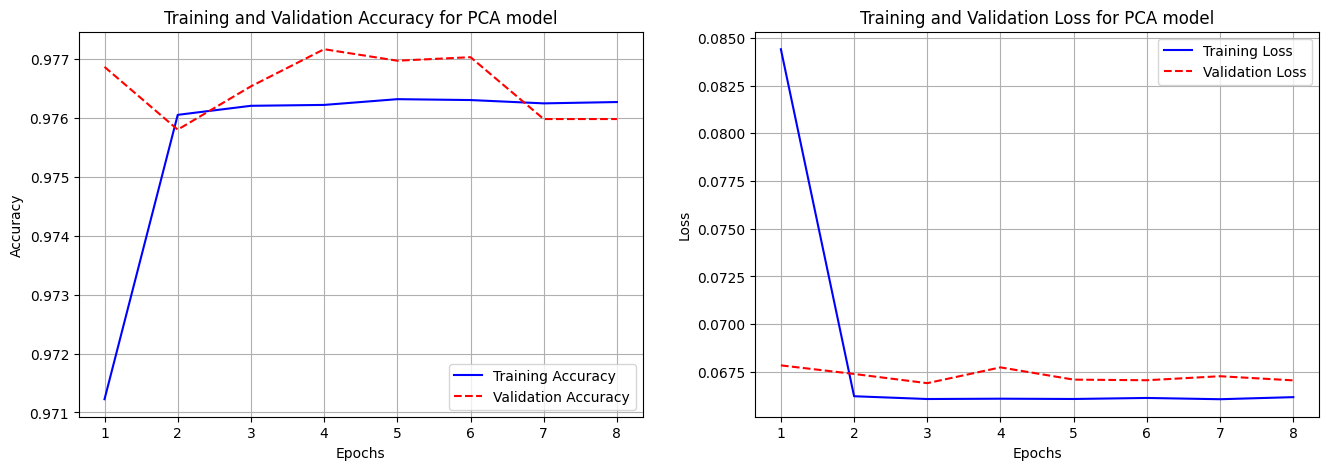

In [ ]:
import matplotlib.pyplot as plt

# Evaluación del modelo con los datos de prueba transformados por PCA
y_pred_proba_pca = model_pca.predict(X_test_pca)
y_pred_pca = (y_pred_proba_pca > 0.5).astype(int)

# Matriz de confusión
cm_pca = confusion_matrix(y_test, y_pred_pca)
disp_pca = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=[0, 1])
disp_pca.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Modelo con PCA)')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.show()

# Cálculo de las métricas
precision_pca = precision_score(y_test, y_pred_pca)
recall_pca = recall_score(y_test, y_pred_pca)
TN_pca = cm_pca[0, 0]
FP_pca = cm_pca[0, 1]
specificity_pca = TN_pca / (TN_pca + FP_pca)
f1_pca = f1_score(y_test, y_pred_pca)

print(f"\nMétricas del Modelo con PCA:")
print(f"Precision: {precision_pca:.4f}")
print(f"Recall: {recall_pca:.4f}")
print(f"Especificidad: {specificity_pca:.4f}")
print(f"F1-Score: {f1_pca:.4f}")

#Gráficas de exactitud y perdida:

# Extraemos los datos del entrenamiento
acc_pca = history_pca.history['accuracy']
val_acc_pca = history_pca.history['val_accuracy']
loss_pca = history_pca.history['loss']
val_loss_pca = history_pca.history['val_loss']

# Creamos un vector para el eje x, usando la longitud de los datos del modelo PCA
epochs_pca = range(1, len(acc_pca) + 1)

# Gráficas lado a lado
plt.figure(figsize=(16, 5))

# Gráfica de Exactitud
plt.subplot(1, 2, 1)
plt.plot(epochs_pca, acc_pca, 'b-', label='Training Accuracy') # Línea azul continua
plt.plot(epochs_pca, val_acc_pca, 'r--', label='Validation Accuracy') # Línea roja punteada
plt.title('Training and Validation Accuracy for PCA model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


# Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_pca, loss_pca, 'b-', label='Training Loss')
plt.plot(epochs_pca, val_loss_pca, 'r--', label='Validation Loss')
plt.title('Training and Validation Loss for PCA model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.show()

La primera gráfica mostrada en este apartado es de una Matriz de Confusión, la cual, como descrita previamente, muestra las predicciones correctas y erróneas hechas por el modelo de PCA.

Las métricas de precisión, recall, especificidad y f1-score siguen siendo altas, mayores al 90%, pero son notablemente menores que las del modelo que no usó el PCA.

Las siguientes dos gráficas comparan la precisión de entrenamiento y validación, y la perdida de entrenamiento y validación:

En la primera de este conjunto, se puede observar que, para los datos del entrenamiento y validación, se alcanza rápidamente una precisión mayor al 0.97, con el último periodo siendo uno que no tiene la precisión de validación más alta. Esto se debe a que se hizo un Early Stop que se enfoca en minimizar el Validation Loss.

Esto se puede observar dentro de la última gráfica del conjunto, en donde el octavo y final periodo es el que tiene la perdida menor, siendo ligeramente más alto que el del entrenamiento.

El rendimiento del modelo con PCA es aceptable, aunque este sea más bajo que el del modelo sin PCA.


In [ ]:
#Guardado del modelo:

# Definir el nombre del archivo para guardar el modelo
model_pca_filename = 'single_neuron_model_ClasificacionDeMonitoreo_pca.keras'

# Guardar el modelo en formato Keras
model_pca.save(model_pca_filename)

# Performance comparison and model selection

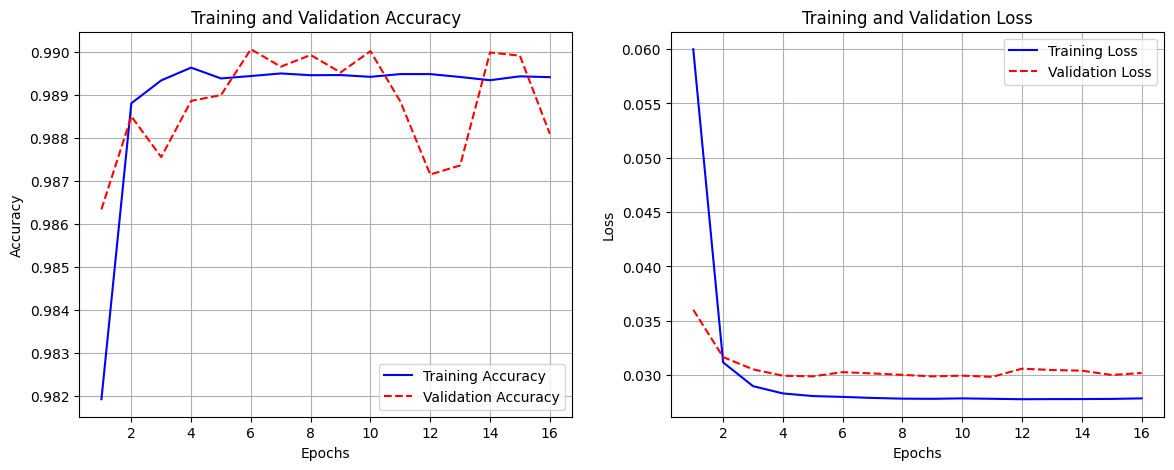

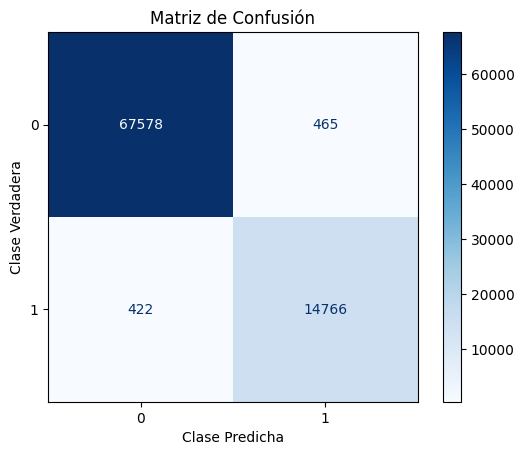


Precision: 0.9695
Recall: 0.9722
Especificidad: 0.9932
F1-Score: 0.9708


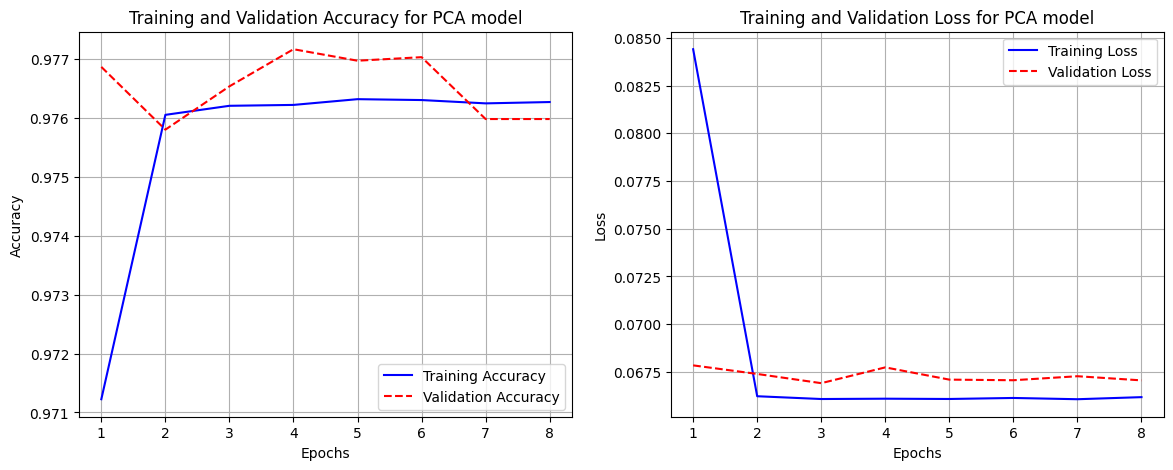

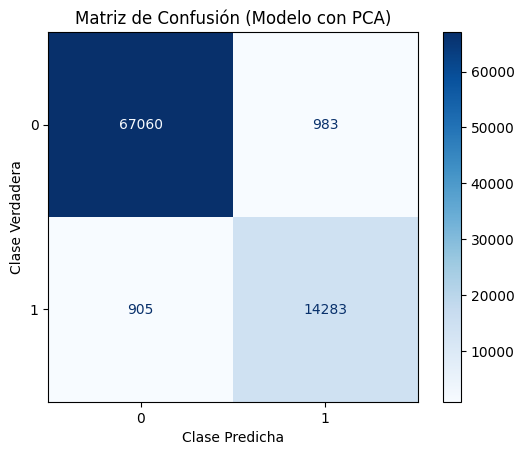


Métricas del Modelo con PCA:
Precision: 0.9356
Recall: 0.9404
Especificidad: 0.9856
F1-Score: 0.9380


In [ ]:
#Modelo sin PCA
# Gráficas lado a lado
plt.figure(figsize=(14, 5))

# Gráfica de Exactitud
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy') # Línea azul continua
plt.plot(epochs, val_acc, 'r--', label='Validation Accuracy') # Línea roja punteada
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


# Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

#Matriz de Confusión sin PCA
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión sin PCA')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.show()
print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Especificidad: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


#Modelo con PCA

# Gráficas lado a lado
plt.figure(figsize=(14, 5))

# Gráfica de Exactitud
plt.subplot(1, 2, 1)
plt.plot(epochs_pca, acc_pca, 'b-', label='Training Accuracy') # Línea azul continua
plt.plot(epochs_pca, val_acc_pca, 'r--', label='Validation Accuracy') # Línea roja punteada
plt.title('Training and Validation Accuracy for PCA model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


# Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_pca, loss_pca, 'b-', label='Training Loss')
plt.plot(epochs_pca, val_loss_pca, 'r--', label='Validation Loss')
plt.title('Training and Validation Loss for PCA model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Matriz de Confusión con PCA
disp_pca.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Modelo con PCA)')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.show()
print(f"\nMétricas del Modelo con PCA:")
print(f"Precision: {precision_pca:.4f}")
print(f"Recall: {recall_pca:.4f}")
print(f"Especificidad: {specificity_pca:.4f}")
print(f"F1-Score: {f1_pca:.4f}")

En ambos modelos donde no se aplicó el uso de PCA y en el que se le aplico tuvieron un entrenamiento bien ajustado donde la exactitud del entrenamiento y validación del modelo sin PCA estaba dentro del rango de 0.98 a 0.99 y la perdida de entrenamiento y validación era abajo de 0.035. Para el modelo con PCA comparte un resultado parecido donde la exactitud está dentro de los valores de 0.97 a 0.98, y la perdida de entrenamiento y validación esta abajo de 0.07.

En la matriz de confusión, el modelo donde no se aplica el uso de PCA llego a tener un resultado más favorable a comparación del modelo donde se aplicó el uso de PCA. Las métricas de **precisión, sensibilidad, especificidad, y F1-Score** aunque para ambos casos sus valores eran mayores a 0.9 siendo un resultado aceptable. En todas las métricas el modelo sin PCA resulto tener resultados más altos y adecuados. La razón de que el modelo con PCA resulto ser menos eficiente aunque la diferencia es pequeña se debe a que de los 9 componentes principales se redujo al uso de 6 componentes, haciendo que el entrenamiento pierda información aunque retenga más del 95% de la varianza. El objetivo principal del PCA no es de mejorar el modelo sino de reducir la dimensionalidad de los datos manteniendo la mayor cantidad de varianza posible.


# Conclusiones personales:

## Mauricio Alejandro González Campos:

Con esta actividad alcanzamos a ver que el PCA no siempre va a resultar en una mejora en el rendimiento del modelo. En nuestro caso, resultó en una disminución pequeña pero notable en todas las métricas: Precisión, Recall, Especificidad y el F1-score, a pesar de que se redujeron 3 dimensiones, de 9 dimensiones a 6 componentes principales requeridos para explicar a >95% de la varianza en los datos.

Creo que mejores resultados serían posibles si el dataset fuera más grande, ya que el que elegimos no era tan grande, pero tuvimos problemas dentro de Google Colab con archivos más grandes.

Recomendamos, para este caso, usar el modelo de una neurona sin PCA para obtener los mejores resultados.

GitHub: https://github.com/MauriGzz555/04-Single-Neuron-Network-with-and-without-PCA


## J. Esteban Bustamante Apodaca

Esta actividad fue de suma ayuda para mi aprendizaje y conocimiento de los temas de inteligencia artificial y el entrenamiento de una sola neurona y la aplicación de PCA. Para este caso donde usamos los datos de sensores para el monitoreo de gas y temperatura de personas de mayor de edad, me ayudo a comprender más sobre el entrenamiento de una sola neurona, donde vi más sobre el uso de herramientas como el optimizador Adam y de la función de perdida con el uso binary cross-entropy para su entrenamiento. Con la comparación de dos modelos donde no se le aplica el uso de PCA y al otro si, vi claramente el impacto que podría tener en el rendimiento del modelo usar PCA para estos datos.

Los resultados que dieron los modelos fueron aceptables, no hubo problemas en el entrenamiento de los modelos como caso de sobreajuste o subajuste, y dentro de la matriz de confusión los resultados de las métricas fueron altos. Se podría mejorar sinceramente, se podría usar mejores hiperparametros o el uso de otras herramientas para el entrenamiento.

Github: https://github.com/EstebanBA-UDEM/Single-Neuron-Network-with-and-without-PCA

## Diego Marcelo Gonzalez Lujan

A través de esta asignacion, comprobamos que estandarizar los datos es importante para la convergencia y estabilidad del modelo. Nos sorprendió que una arquitectura como la de una sola neurona lograra un rendimiento predictivo alto. Al aplicar PCA, observamos que logramos comprimir la informacion a 6 componentes conservando el 95% de la varianza, a cambio una ligera caida en la métrica final.


Como limitación, el estudio dependió de una única partición estática de datos y de un modelo lineal. Para aplicaciones prácticas en sistemas de automatización, implementar validación cruzada para darle mayor robustez a la evaluación.

## Bibliografía

Marín López, D., Marín, D., Fonollosa, J., Llano, J., Perera, A., & Haddi, Z. (2023). Single elder home monitoring: Gas and position [Dataset]. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/799/single+elder+home+monitoring+gas+and+position